# Расследование II-01 · Ирисовый экзамен

**Бюро аналитических расследований, 6 апреля 2026 года.** В записке о найме Вера Орлова указала: кандидат приглашён после отчёта по «Северному столу»; решающим стало умение отделить действие учётной записи от личности человека и безопасное решение — от обвинения. Теперь то же различие нужно провести между метрикой и доказательством качества.

Поставщик «Компаса» показывает классификатор ирисов со 100% accuracy. Ваша задача — воспроизвести демонстрацию, построить корректную процедуру оценки и написать вывод, который не утверждает больше, чем позволяют данные.

**Для кого:** новый младший аналитик Бюро, знакомый с функциями, коллекциями и файлами. Опыт с pandas и scikit-learn не требуется.

**К концу расследования вы сможете:** читать табличный датасет, отделять `X` от `y`, делать стратифицированное разбиение, строить базовую модель и конвейер k-NN, интерпретировать accuracy и матрицу ошибок.


## Маршрут расследования

1. Прочитать локальный CSV в `DataFrame` и проверить его SHA-256.
2. Увидеть геометрию четырёх признаков.
3. Зафиксировать стратифицированное разбиение на обучающую и тестовую выборки.
4. Воспроизвести «идеальную» демонстрацию поставщика.
5. Сравнить базовую модель и k-NN, не подглядывая в тестовую выборку.
6. Разобрать ошибки и составить аудиторскую записку.

Ориентир времени — 3–4 часа. Не гонитесь за максимальным числом: объяснимый процесс важнее ещё одной сотой доли правильных ответов (accuracy).


In [1]:
from __future__ import annotations

import hashlib
import random
import urllib.request
import zipfile
from pathlib import Path

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
NOTEBOOK_VARIANT = "solution"
CASE_SLUG = "case-01"
ARCHIVE_NAME = "part-2-case-01.zip"
COURSE_SITE = "https://mkuziuk.github.io/python-tutorial"
IN_COLAB = False

# При локальном запуске используем файлы из каталога расследования; в Colab скачиваем архив и проверяем его SHA-256.
# Импорт google.colab проходит только в Colab; локально возникает ImportError, и IN_COLAB остаётся False.
try:
    import google.colab  # type: ignore[import-not-found]  # noqa: F401
    IN_COLAB = True
except ImportError:
    pass

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def find_local_case() -> Path | None:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "README.md").exists()
            and (candidate / f"{CASE_SLUG}.ipynb").exists()
        ):
            return candidate
        nested = candidate / "projects" / "part-2" / CASE_SLUG
        if (nested / "README.md").exists():
            return nested
    return None

def download_colab_case() -> Path:
    destination = Path("/content") / f"python-tutorial-{CASE_SLUG}"
    destination.mkdir(parents=True, exist_ok=True)
    archive_path = destination / ARCHIVE_NAME
    archive_url = f"{COURSE_SITE}/downloads/{ARCHIVE_NAME}"
    checksum_url = f"{archive_url}.sha256"

    urllib.request.urlretrieve(archive_url, archive_path)
    # Сравниваем SHA-256 архива с опубликованной контрольной суммой перед распаковкой.
    with urllib.request.urlopen(checksum_url) as response:
        expected = response.read().decode("utf-8").split()[0].lower()
    actual = sha256_file(archive_path)
    if actual != expected:
        raise RuntimeError(f"SHA-256 архива не совпал: {actual} != {expected}")

    unpacked = destination / "unpacked"
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(unpacked)
    matches = sorted(unpacked.rglob(f"{CASE_SLUG}.ipynb"))
    if not matches:
        raise FileNotFoundError(f"В архиве нет {CASE_SLUG}.ipynb")
    return matches[0].parent

# DATA_DIR и ARTIFACTS_DIR строятся от найденного каталога расследования, поэтому текущая папка не влияет на пути.
CASE_DIR = find_local_case()
if CASE_DIR is None and IN_COLAB:
    CASE_DIR = download_colab_case()
if CASE_DIR is None:
    raise FileNotFoundError(
        f"Не найден каталог {CASE_SLUG}. Запустите тетрадь из каталога расследования."
    )

DATA_DIR = CASE_DIR / "data"
print(f"Среда: {'Colab' if IN_COLAB else 'local'} | расследование: {CASE_DIR}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


Среда: local | расследование: /private/var/folders/fv/ts0wlkms131g6wghvr6zgnpm0000gn/T/python-tutorial-part2-run-y2wh8jce/case-01
RANDOM_STATE = 42


In [2]:
import json
import warnings
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


## 1. Карточка источника и чтение CSV

Iris содержит 150 растений, четыре измерения в сантиметрах и три класса. В архив вложен замороженный файл `data/iris.csv` (идентификатор курса `sklearn-iris`), поэтому выполнение не зависит от сети. Атрибуция и ссылки записаны в `data/SOURCE.md`.

Следующая ячейка получает путь `DATA_DIR`, читает карточку `dataset_manifest.json`, сверяет SHA-256 и только после этого создаёт `frame` вызовом `pd.read_csv()`. Ожидаемый результат — `DataFrame` с одной строкой на цветок, четырьмя числовыми признаками и двумя представлениями класса: кодом и названием.

Важное ограничение: это маленький, чистый учебный набор. Он помогает понять процедуру, но не имитирует шум, дрейф и неоднозначную разметку реальной лаборатории.


In [3]:
manifest = json.loads((DATA_DIR / "dataset_manifest.json").read_text(encoding="utf-8"))
data_path = DATA_DIR / manifest["filename"]
actual_sha256 = sha256_file(data_path)
assert actual_sha256 == manifest["sha256"], "SHA-256 iris.csv не совпадает с карточкой"

frame = pd.read_csv(data_path)
feature_names = list(manifest["feature_names"])
species_by_code = dict(enumerate(manifest["classes"]))
class_names = [species_by_code[code] for code in sorted(species_by_code)]

assert frame.shape == (manifest["rows"], manifest["columns"])
assert frame["species_code"].map(species_by_code).eq(frame["species"]).all()
print(f"Файл: {data_path.name} | SHA-256: {actual_sha256[:12]}…")
print(f"Наблюдений: {len(frame)} | столбцов: {frame.shape[1]}")
display(frame.head())


Файл: iris.csv | SHA-256: 926abf13e580…
Наблюдений: 150 | столбцов: 6


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


**Что подтвердила загрузка.** Контрольная сумма связывает анализ с конкретным снимком, а первые строки подтверждают ожидаемую структуру «один цветок → четыре измерения → код и название вида». До моделирования нужно проверить типы, пропуски и диапазоны по всей таблице, поэтому следующий этап — компактный audit столбцов и классов.


In [4]:
audit = pd.DataFrame(
    {
        "dtype": frame.dtypes.astype(str),
        "missing": frame.isna().sum(),
        "unique": frame.nunique(),
    }
)
numeric_ranges = frame[feature_names].agg(["min", "max"]).T
duplicate_count = int(frame.duplicated().sum())
target_audit = (
    frame["species"]
    .value_counts()
    .rename("count")
    .to_frame()
    .assign(share=lambda table: table["count"] / len(frame))
)

display(audit)
display(numeric_ranges)
print("Полных дубликатов строк:", duplicate_count)
display(target_audit)
display(frame.groupby("species")[feature_names].agg(["mean", "std"]).round(2))


,dtype,missing,unique
sepal length (cm),float64,0,35
sepal width (cm),float64,0,23
petal length (cm),float64,0,43
petal width (cm),float64,0,22
species_code,int64,0,3
species,str,0,3


,min,max
sepal length (cm),4.3,7.9
sepal width (cm),2.0,4.4
petal length (cm),1.0,6.9
petal width (cm),0.1,2.5


Полных дубликатов строк: 1


,count,share
species,,
setosa,50,0.333333
versicolor,50,0.333333
virginica,50,0.333333


sepal length (cm)       sepal width (cm)       petal length (cm)  \
                        mean   std             mean   std              mean   
species                                                                       
setosa                  5.01  0.35             3.43  0.38              1.46   
versicolor              5.94  0.52             2.77  0.31              4.26   
virginica               6.59  0.64             2.97  0.32              5.55   

                 petal width (cm)        
             std             mean   std  
species                                  
setosa      0.17             0.25  0.11  
versicolor  0.47             1.33  0.20  
virginica   0.55             2.03  0.27

**Что показал audit.** Четыре признака прочитаны как числа, пропуски и полные дубликаты строк отсутствуют. Таблица `numeric_ranges` фиксирует минимумы и максимумы в сантиметрах, а `target_audit` подтверждает по 50 наблюдений каждого вида. Различия средних по видам полезны только как описательная разведка всей таблицы; они не участвуют в выборе модели. Теперь можно отделить признаки `X` от цели `y`, заморозить внешний test и больше не обращаться к нему до фиксации `k` и baseline.


## 2. Постановка как классификация

**Единица наблюдения** — один цветок. **Признаки** — длина и ширина чашелистика и лепестка. **Цель** — вид. На момент измерения все четыре признака доступны, поэтому временной утечки здесь нет.

Обозначения:

- `X` — матрица формы `(число_цветков, 4)`;
- `y` — вектор кодов класса длины `число_цветков`.


In [5]:
X = frame[feature_names]
y = frame["species_code"]

print("X:", X.shape, "| y:", y.shape)
display(y.value_counts(normalize=True).rename(index=species_by_code).to_frame("share"))


X: (150, 4) | y: (150,)


,share
species_code,
setosa,0.333333
versicolor,0.333333
virginica,0.333333


**Граница постановки.** `X` содержит только четыре измерения цветка, а `y` — только код вида; текстовое название класса не попадает в признаки. Доли классов близки, но это не отменяет базовую модель. Прежде чем делить данные, посмотрим, где классы разделяются геометрически.


## 3. Замораживаем внешний экзамен

Следующая ячейка получает `X` формы `(число_цветков, 4)` и вектор `y`. `train_test_split()` вернёт четыре объекта: признаки и метки для обучения и для внешней проверки. Параметр `stratify=y` сохраняет доли классов, а `random_state` делает конкретное разбиение воспроизводимым.

Тестовую выборку откладываем один раз и не используем для выбора `k`. Иначе экзамен постепенно превращается в часть подготовки. Таблица `split_summary` должна показать по одной строке на вид и две колонки с долями — для train и test.


In [6]:
# Выбираем k по X_train; X_test используем один раз для итоговой оценки.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.concat(
    [
        y_train.value_counts(normalize=True).sort_index().rename("train_share"),
        y_test.value_counts(normalize=True).sort_index().rename("test_share"),
    ],
    axis=1,
).rename(index=species_by_code)
display(split_summary.round(3))
print("train:", len(X_train), "| test:", len(X_test))


,train_share,test_share
species_code,,
setosa,0.339,0.316
versicolor,0.330,0.342
virginica,0.330,0.342


train: 112 | test: 38


**Что подтвердило разбиение.** Train больше test, в обеих частях присутствуют три вида, а близкие доли в `split_summary` подтверждают работу стратификации. Индексы частей не пересекаются. Мы зафиксировали внешний экзамен; до ячейки итоговой оценки код использует только `X_train` и `y_train`. Для разведки далее строится график всей исходной таблицы, но его наблюдения не меняют список кандидатов `k`.


### Визуальная разведка

Вход следующей ячейки — `plot_frame`: четыре числовых признака и известный вид. `sns.pairplot()` вернёт сетку попарных диаграмм; каждая точка обозначает цветок, а цвет — класс. Мы проверяем, какие пары измерений визуально разделяют виды и где классы перекрываются. График описывает уже размеченную выборку и сам по себе не оценивает качество модели.


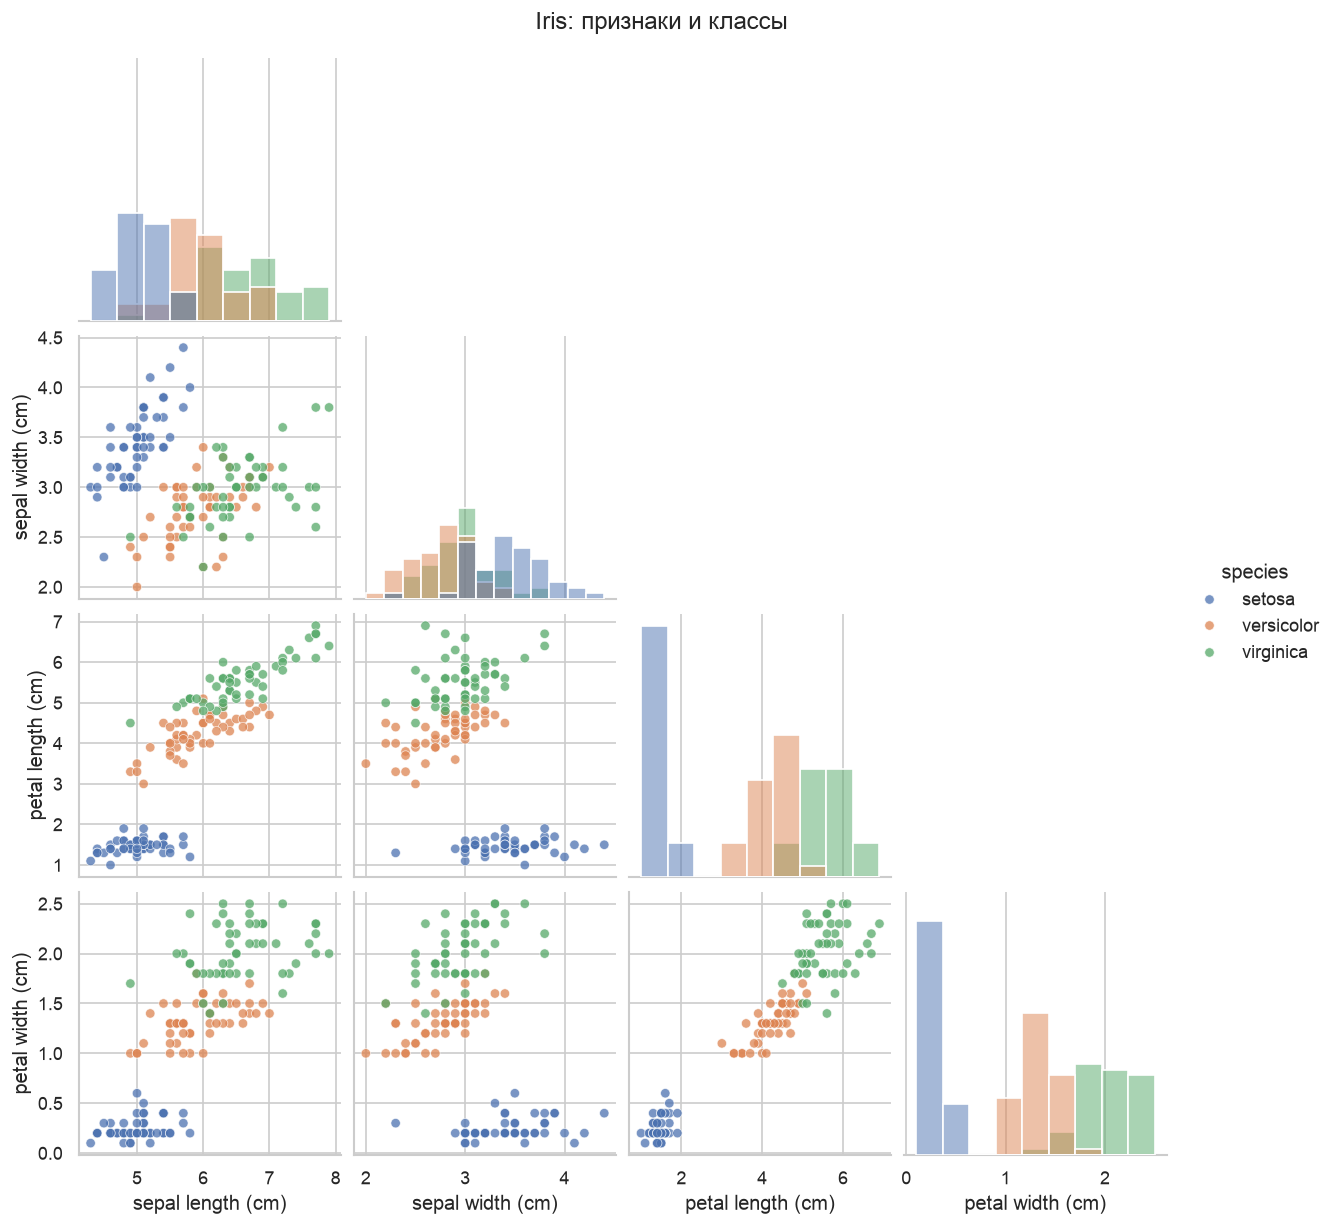

In [7]:
plot_frame = frame[feature_names + ["species"]]
grid = sns.pairplot(
    plot_frame,
    hue="species",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.75, "s": 32},
)
grid.figure.suptitle("Iris: признаки и классы", y=1.02)

# Явно кодируем PNG, чтобы nbclient сохранил график даже с невизуальным backend Agg.
pairplot_png = BytesIO()
grid.figure.savefig(pairplot_png, format="png", bbox_inches="tight", dpi=120)
plt.close(grid.figure)
display(Image(data=pairplot_png.getvalue()))


**Наблюдение по графику.** Вид setosa образует отдельную область прежде всего по длине и ширине лепестка. Versicolor и virginica ближе друг к другу и частично перекрываются — именно между ними разумно ожидать ошибки. Это описательное наблюдение использует известные метки; для оценки новых цветков теперь нужен отдельный внешний test.


## 4. Откуда взялись 100%

Антон Карев прислал только одну строку: «accuracy = 1.00». Восстановим наиболее вероятный сценарий: k-NN с `k=1` проверили на тех же строках, которые он запомнил.

Для `k=1` ближайший сосед обучающей точки — она сама, расстояние равно нулю. Это проверка памяти, а не новых данных.


In [8]:
vendor_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1))
vendor_model.fit(X, y)
vendor_training_accuracy = vendor_model.score(X, y)
print(f"Метрика демонстрации на обучающих данных: {vendor_training_accuracy:.3f}")


Метрика демонстрации на обучающих данных: 1.000


**Граница демонстрации.** Напечатанная accuracy относится к тем же строкам, на которых обучен `k=1`: каждая строка оказывается собственным ближайшим соседом. Результат воспроизводит заявление, но не измеряет обобщение. Для осмысленного сравнения дальше нужны расстояние в масштабированном пространстве и внешняя базовая модель.


## 5. Как k-NN принимает решение

После масштабирования расстояние между точками $a$ и $b$:

$$d(a,b)=\sqrt{\sum_{j=1}^{p}(a_j-b_j)^2}$$

Масштабирование важно: иначе признак с большим числовым диапазоном сильнее влияет на сумму. k-NN выбирает `k` ближайших обучающих точек и голосует по их классам.

Следующая ячейка вычисляет расстояние между первыми двумя масштабированными объектами двумя способами: по формуле и через `np.linalg.norm`. На входе `X_train`, на выходе — два скалярных числа, которые должны совпасть.


In [9]:
scaler_demo = StandardScaler().fit(X_train)
scaled_train = scaler_demo.transform(X_train)

# В масштабированном пространстве все четыре измерения вносят сопоставимый вклад.
delta = scaled_train[0] - scaled_train[1]
distance_manual = float(np.sqrt(np.sum(delta**2)))
distance_numpy = float(np.linalg.norm(delta))

print(f"Вручную: {distance_manual:.6f} | np.linalg.norm: {distance_numpy:.6f}")


Вручную: 0.505864 | np.linalg.norm: 0.505864


**Проверка вычисления.** Ручная сумма квадратов и `np.linalg.norm` дают одно и то же расстояние между выбранными строками. Это подтверждает реализацию евклидовой дистанции, но одна пара не характеризует качество классификатора. Следующий шаг — измерить нижнюю планку accuracy на отложенном test.


### Сначала базовая модель

`DummyClassifier` игнорирует четыре признака и всегда выбирает самый частый класс обучающей выборки. Следующая ячейка получает `X_train`, `y_train`, делает прогноз для `X_test` и возвращает одну скалярную метрику `baseline_accuracy`.

Accuracy — доля правильных ответов:

$$accuracy=\frac{\text{число верных прогнозов}}{\text{все прогнозы}}$$

Значение лежит от 0 до 1; чем оно выше, тем больше верных прогнозов. Если k-NN не превосходит эту нижнюю планку на тех же тестовых строках, усложнение модели не обосновано.


In [10]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_class = int(baseline.classes_[np.argmax(baseline.class_prior_)])
print(
    "Baseline зафиксирован до открытия test: "
    f"всегда предсказывать {species_by_code[baseline_class]!r}; "
    f"доля класса в train={baseline.class_prior_.max():.3f}"
)


Baseline зафиксирован до открытия test: всегда предсказывать 'setosa'; доля класса в train=0.339


**Смысл baseline.** Dummy зафиксировал правило по `y_train`: всегда выбирать самый частый обучающий класс. Напечатанная доля — характеристика train, а не итоговая test accuracy. Внешний test остаётся закрытым; теперь на одинаковых внутренних CV-разбиениях `X_train` выберем `k`, после чего оба уже зафиксированных решения будут оценены одним блоком.


### Выбираем `k` только внутри обучающей выборки

Следующая ячейка получает только `X_train` и `y_train`. `StratifiedKFold` делит обучение на пять внутренних частей; каждая по очереди служит проверкой. Для каждого кандидата `k` код собирает строку таблицы `cv_results` с числом соседей, средней accuracy и её разбросом между пятью разбиениями.

Внешние `X_test` и `y_test` здесь не используются. `selected_k` берётся из верхней строки отсортированной таблицы; при равной средней accuracy выбран меньший `k`.


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
candidate_rows = []

# Значение k выбираем только по внутренней кросс-валидации обучающей выборки.
for k in (1, 3, 5, 7, 9, 11):
    candidate = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=1)
    candidate_rows.append(
        {
            "k": k,
            "cv_accuracy_mean": scores["test_score"].mean(),
            "cv_accuracy_std": scores["test_score"].std(),
        }
    )

cv_results = pd.DataFrame(candidate_rows).sort_values(
    ["cv_accuracy_mean", "k"], ascending=[False, True]
)
display(cv_results.round(3))
selected_k = int(cv_results.iloc[0]["k"])
print("Выбран k =", selected_k)


,k,cv_accuracy_mean,cv_accuracy_std
1,3,0.973,0.022
3,7,0.965,0.051
2,5,0.964,0.033
4,9,0.956,0.048
5,11,0.956,0.048
0,1,0.928,0.053


Выбран k = 3


**Что решает CV.** Верхняя строка `cv_results` определяет `selected_k` без обращения к внешнему test; разброс показывает чувствительность оценки к конкретной внутренней части. CV выбирает конфигурацию, но не заменяет итоговый экзамен. Теперь обучим выбранный конвейер на всём train и ровно один раз сравним Dummy и k-NN на test.


In [12]:
# После выбора k фиксируем итоговый Pipeline на X_train.
final_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=selected_k),
)
final_model.fit(X_train, y_train)

# Только теперь один блок открывает внешний test для обоих заранее зафиксированных правил.
baseline_predictions = baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
test_predictions = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)

comparison = pd.DataFrame(
    [
        {"scenario": "dummy / внешний test", "accuracy": baseline_accuracy, "valid_generalization_check": True},
        {"scenario": "k-NN / внешний test", "accuracy": test_accuracy, "valid_generalization_check": True},
        {"scenario": "vendor / train", "accuracy": vendor_training_accuracy, "valid_generalization_check": False},
    ]
)
display(comparison.round(3))


,scenario,accuracy,valid_generalization_check
0,dummy / внешний test,0.316,True
1,k-NN / внешний test,0.921,True
2,vendor / train,1.000,False


**Сравнение на общей границе.** Строки Dummy и k-NN используют один внешний test, поэтому их accuracy сопоставимы. Строка vendor использует train и помечена как непригодная для проверки обобщения: её нельзя ранжировать рядом с внешними оценками как равноправный результат. Одно число скрывает направление промахов, поэтому далее разложим прогнозы в матрицу ошибок.


## 6. Не только одно число

Следующая ячейка получает два вектора одинаковой длины: истинные метки `y_test` и прогнозы `test_predictions`. `confusion_matrix()` создаёт массив формы `3 × 3`: строка — истинный вид, столбец — предсказанный. Диагональ означает верные ответы, внедиагональные ячейки — направление ошибок. Затем тот же массив будет показан как таблица и как тепловая карта.


,setosa,versicolor,virginica
setosa,12,0,0
versicolor,0,13,0
virginica,0,3,10


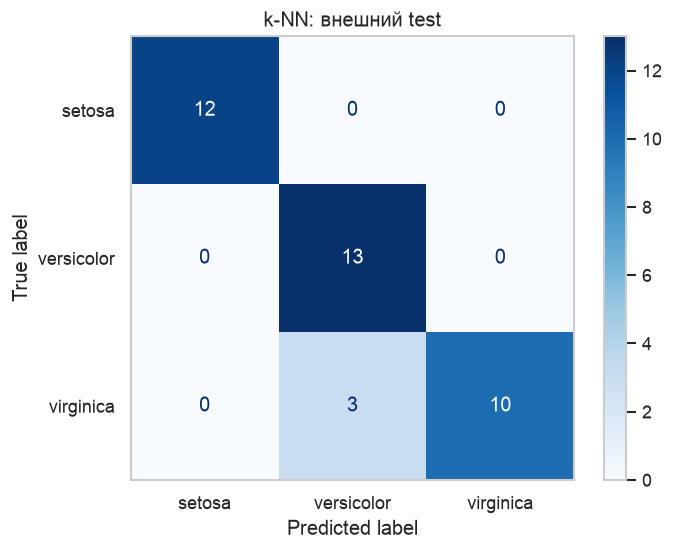

In [13]:
# Строки матрицы — истинные классы, столбцы — предсказанные.
matrix = confusion_matrix(y_test, test_predictions, labels=[0, 1, 2])
display(pd.DataFrame(matrix, index=class_names, columns=class_names))

confusion_display = ConfusionMatrixDisplay(
    matrix, display_labels=class_names
).plot(cmap="Blues")
confusion_display.ax_.set_title("k-NN: внешний test")
confusion_display.ax_.grid(False)

# Сохраняем PNG в output ячейки независимо от интерактивности matplotlib backend.
confusion_png = BytesIO()
confusion_display.figure_.savefig(
    confusion_png, format="png", bbox_inches="tight", dpi=120
)
plt.close(confusion_display.figure_)
display(Image(data=confusion_png.getvalue()))


**Наблюдение по матрице.** Основная масса находится на диагонали; setosa отделяется без той путаницы, которая остаётся между близкими versicolor и virginica. Матрица показывает направления ошибок, но не сами измерения спорных цветков. Следующий этап свяжет внедиагональные ячейки с исходными строками test.


### Реестр ошибок

Следующая ячейка получает `X_test`, `y_test` и `test_predictions`. Она копирует тестовые признаки, добавляет текстовые столбцы `actual` и `predicted`, затем оставляет только несовпадения. Результат `errors` — таблица «индекс исходной строки → четыре измерения → истинный вид → прогноз», пригодная для разбора каждого промаха.


In [14]:
errors = X_test.copy()
errors["actual"] = y_test.map(species_by_code)
errors["predicted"] = pd.Series(test_predictions, index=y_test.index).map(species_by_code)
errors = errors.loc[errors["actual"] != errors["predicted"]].sort_index()
print(f"Ошибок: {len(errors)} из {len(y_test)}")
display(errors)


Ошибок: 3 из 38


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual,predicted
106,4.9,2.5,4.5,1.7,virginica,versicolor
134,6.1,2.6,5.6,1.4,virginica,versicolor
138,6.0,3.0,4.8,1.8,virginica,versicolor


**Что даёт реестр.** Таблица локализует промахи в области близких измерений versicolor и virginica; для каждой строки видны истинный и предсказанный классы. Это описание ошибок на небольшой тестовой выборке, а не доказательство общей частоты путаницы в природе. Теперь можно написать записку, опираясь отдельно на процедуру, метрику и конкретные ошибки.


> **Типичная ошибка:** попробовать несколько `k` на тестовой выборке и оставить лучший. Тогда тестовая выборка уже участвует в выборе и перестаёт быть независимым экзаменом. Выбор делаем по кросс-валидации обучающей выборки; тестовую используем один раз.

**Дополнительное исследование:** повторите внутренний CV без `StandardScaler` и объясните, почему разница на Iris может быть небольшой, хотя правило масштабировать модели, основанные на расстоянии остаётся важным.


## 7. Аудиторская записка

Следующая ячейка собирает словарь `audit_memo` из пяти обязательных разделов и показывает его как таблицу. Вход — уже вычисленные размер полной выборки и внешняя accuracy; результат отделяет наблюдаемый факт от интерпретации, недоказанных утверждений, ограничений и действия.


In [15]:
audit_memo = {
    "established_fact": (
        f"Заявленные 100% воспроизводятся при оценке k=1 на тех же {len(X)} строках, "
        f"на которых модель обучена; accuracy на независимой тестовой выборке равна {test_accuracy:.3f}."
    ),
    "supported_interpretation": (
        "Демонстрация измеряет запоминание обучающей выборки и не подтверждает "
        "обобщение на новые измерения."
    ),
    "not_proven": (
        "По переданным материалам нельзя установить умысел конкретного сотрудника "
        "или качество системы на данных Бюро."
    ),
    "limitations": (
        "Iris мал, чист и не отражает реальные ошибки измерения, дрейф и новые виды."
    ),
    "recommended_action": (
        "Запросить протокол разбиения и повторить независимую предметную проверку "
        "до использования «Компаса»."
    ),
}
display(pd.Series(audit_memo, name="Записка II-01").to_frame())


,Записка II-01
established_fact,Заявленные 100% воспроизводятся при оценке k=1...
supported_interpretation,Демонстрация измеряет запоминание обучающей вы...
not_proven,По переданным материалам нельзя установить умы...
limitations,"Iris мал, чист и не отражает реальные ошибки и..."
recommended_action,Запросить протокол разбиения и повторить незав...


**Интерпретация вывода.** Проблема не в самом k-NN и не в том, что accuracy на тестовой выборке ниже единицы. Нарушена связь между заявлением и измерением: accuracy на обучающей выборке не отвечает на вопрос о новых объектах. Данные устанавливают ошибку процедуры, но не умысел конкретного человека.


In [16]:
# Средние StandardScaler должны совпадать со средними X_train; иначе масштабирование обучалось на других данных.
fitted_scaler = final_model.named_steps["standardscaler"]
train_feature_means = X_train.mean().to_numpy()
all_feature_means = X.mean().to_numpy()
scaler_fit_on_train_only = (
    np.allclose(fitted_scaler.mean_, train_feature_means)
    and not np.allclose(fitted_scaler.mean_, all_feature_means)
)

checks = {
    "split_disjoint": set(X_train.index).isdisjoint(X_test.index),
    "all_classes_in_both": y_train.nunique() == y_test.nunique() == 3,
    "matrix_covers_test": int(matrix.sum()) == len(y_test),
    "beats_baseline": test_accuracy > baseline_accuracy,
    "test_accuracy_in_broad_range": 0.85 < test_accuracy < 1.0,
    "scaler_fit_on_train_only": scaler_fit_on_train_only,
    "vendor_is_train_score": vendor_training_accuracy == 1.0,
}
display(pd.Series(checks, name="passed").to_frame())
if NOTEBOOK_VARIANT == "solution":
    assert all(checks.values())
    assert np.allclose(fitted_scaler.mean_, X_train.mean().to_numpy())
    assert not np.allclose(fitted_scaler.mean_, X.mean().to_numpy())
    assert np.isclose(distance_manual, distance_numpy)
else:
    print("Строгие проверки выполняются в тетради с полным разбором.")


,passed
split_disjoint,True
all_classes_in_both,True
matrix_covers_test,True
beats_baseline,True
test_accuracy_in_broad_range,True
scaler_fit_on_train_only,True
vendor_is_train_score,True


**Итог проверки.** Таблица `checks` подтверждает непересекающиеся части, покрытие test матрицей ошибок, превосходство над baseline и обучение `StandardScaler` только на `X_train`. Эти инварианты проверяют процедуру, но не устраняют ограничения малого учебного датасета.


## Расследование закрыто

Перед сдачей перезапустите kernel и выполните **Run All**. Сверьте не отдельное число, а всю цепочку с `check_result.md`. Следующее расследование покажет более опасную ошибку: модель может корректно оцениваться на тестовой выборке и всё равно знать будущее через признаки.
